In [1]:
#Bias varience tradeoff lecture lab

In [2]:
from sklearn.linear_model import Lasso
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [5]:
np.random.seed(42)

x = np.linspace(0, 10, 200).reshape(-1, 1)

In [6]:
y = 2 + 0.5 * x[:, 0] ** 2 + np.random.normal(50, 15, 200)

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [8]:
degrees = [1, 2, 10]

In [9]:
for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(x_train, y_train)

    train_prediction = model.predict(x_train)
    test_prediction = model.predict(x_test)

    train_mse = mean_squared_error(y_train, train_prediction)
    test_mse = mean_squared_error(y_test, test_prediction)

    print("Ploynomial Degree: ", degree)
    print("Train mse", train_mse)
    print("Test mse", test_mse)
    print()

Ploynomial Degree:  1
Train mse 218.44366351650478
Test mse 175.3138698115998

Ploynomial Degree:  2
Train mse 201.20346474988483
Test mse 177.03395996559343

Ploynomial Degree:  10
Train mse 188.82080066192697
Test mse 186.33643137660337



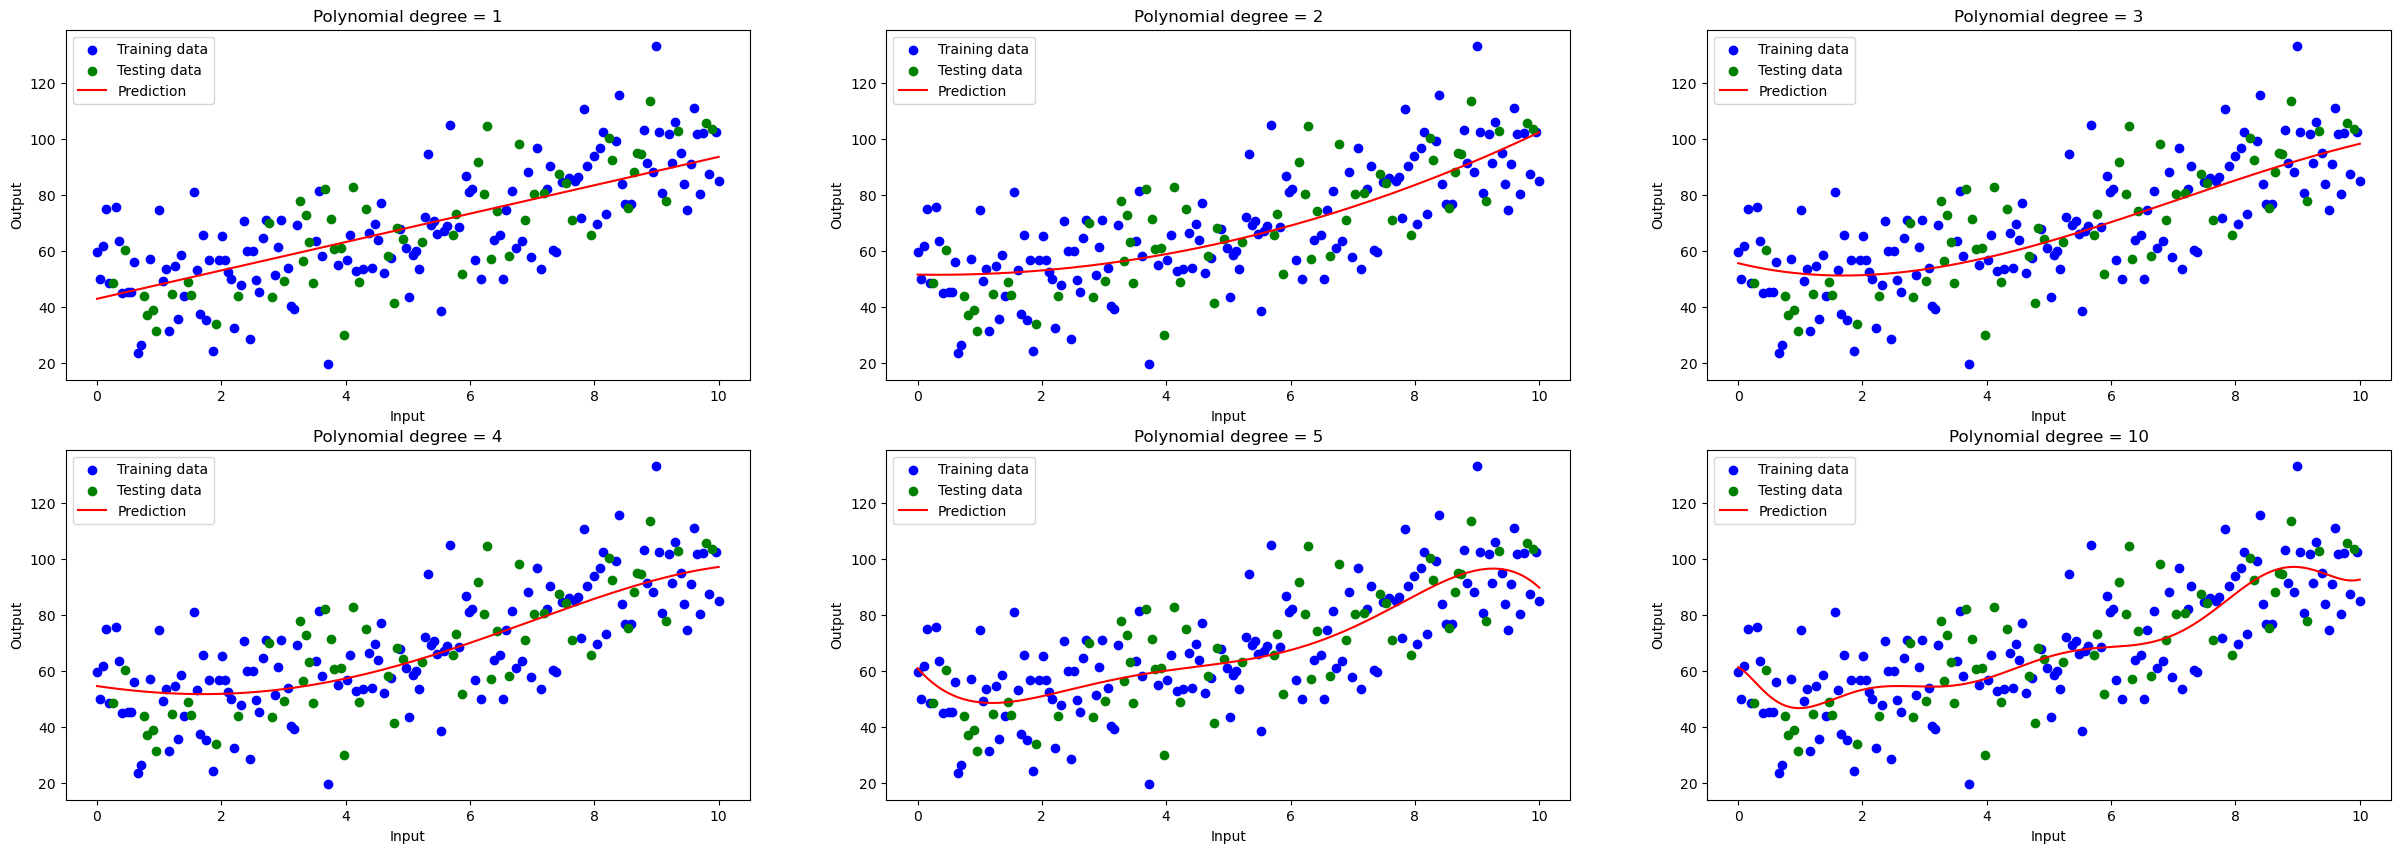

In [18]:
degreess = [1, 2, 3, 4, 5, 10]
x_plot = np.linspace(0, 10, 200).reshape(-1, 1)

plt.figure(figsize=(30, 10))

for index, degree in enumerate(degreess):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(x_train, y_train)
    y_plot = model.predict(x_plot)

    plt.subplot(2, 3, index+1)
    plt.scatter(x_train, y_train, color="blue", label="Training data")
    plt.scatter(x_test, y_test, color="green", label="Testing data")
    plt.plot(x_plot, y_plot, color="red", label="Prediction")

    plt.title(f"Polynomial degree = {degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()

# plt.tight_layout()
plt.show()